## Linear Regression from Scratch

### Cell 1 — Imports & Training Data

We use 3 libraries:
- `numpy` — math and array operations
- `matplotlib` — plotting
- `math` — for `math.ceil()` in the print interval logic

**Training data:**
- `x_train` — house size in **1000s of sqft** (already scaled — dividing by 1000 keeps gradients small so gradient descent converges)
- `y_train` — price in **$1000s**

Feature scaling is critical here. Raw sqft values (1000–3000) cause gradients to explode with any reasonable learning rate.

In [233]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Load our data set — size (1000 sqft), price ($1000s)
x_train = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
y_train = np.array([200,  270,  350,  430,  500 ])


### Cell 2 — Cost Function (Mean Squared Error)

Calculates how wrong our current `w` and `b` are across all training examples.

**Formula:**

    J(w,b) = (1/2m) * Σ (ŷᵢ - yᵢ)²

**Code breakdown:**
- `m = x.shape[0]` — number of training examples (rows in x)
- `f_wb = w * x[i] + b` — prediction for example i (same as ŷᵢ)
- `(f_wb - y[i])**2` — squared error for example i
- accumulate all squared errors into `cost`, then multiply by `1/2m`

**Why squared?** Squaring makes all errors positive and penalizes 
large mistakes more than small ones.

**Why 1/2?** Pure convenience — the 2 cancels when we take the 
derivative in the next step, giving a cleaner gradient formula.

**Goal:** minimize J. The smaller J is, the better our line fits the data.

In [234]:
#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

### Cell 3 — Compute Gradients

Calculates the partial derivatives of J — tells gradient descent 
which direction to move w and b to reduce cost.

**Formulas:**

    ∂J/∂w = (1/m) * Σ (ŷᵢ - yᵢ) * xᵢ
    ∂J/∂b = (1/m) * Σ (ŷᵢ - yᵢ)

**Code breakdown:**
- `f_wb = w * x[i] + b` — prediction for example i
- `dj_dw_i = (f_wb - y[i]) * x[i]` — gradient contribution of example i for w
- `dj_db_i = f_wb - y[i]` — gradient contribution of example i for b
- accumulate both across all m examples, then divide by m at the end

**Why divide by m outside the loop?**
More efficient — one division instead of m divisions.
Same mathematical result.

**What the gradient tells us:**
- Positive → parameter is too high → gradient descent will decrease it
- Negative → parameter is too low → gradient descent will increase it
- Zero → we're at the minimum ✓

**w.r.t.** in the docstring means "with respect to" — standard 
math shorthand for partial derivatives.

In [235]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

### Cell 4 — Gradient Descent

The main training loop. Repeatedly updates w and b using the 
gradients until we converge on the best fit line.

**Update rule (runs every iteration):**

    w := w - α * (∂J/∂w)
    b := b - α * (∂J/∂b)

**Code breakdown:**
- `w_in, b_in` — starting values, both 0 at the beginning
- `alpha` — learning rate, controls step size
- `cost_function, gradient_function` — passed in as arguments,
  making this function reusable for any model, not just linear regression
- `J_history` — stores cost at every iteration (used for plotting)
- `p_history` — stores [w, b] at every iteration (used for plotting)

**The update order matters:**
Both gradients are computed FIRST via `gradient_function()`,
then w and b are updated. This is simultaneous update — critical.
If you updated w first and used the new w to compute dj_db, 
you'd be doing something mathematically different.

**`if i < 100000` guard:**
Prevents memory exhaustion if someone passes in a huge num_iters.
Only saves the first 100,000 entries to J_history and p_history.

**`math.ceil(num_iters/10)`:**
Prints exactly 10 status updates regardless of how many 
iterations you run. ceil() handles cases where num_iters 
isn't cleanly divisible by 10.

**Returns 4 values:**
- `w, b` — final trained parameters (use these to predict)
- `J_history` — to plot cost vs iteration curve
- `p_history` — to animate or inspect how w,b changed over time

In [236]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

### Cell 5 — Run Gradient Descent

Plugs everything together and trains the model.

**Hyperparameters chosen:**
- `w_init = 0, b_init = 0` — start with a flat line, let gradient 
  descent find the right values from scratch
- `iterations = 10000` — number of training steps
- `tmp_alpha = 5e-2` — learning rate (0.05)

**Why these specific values?**
x_train is already scaled (divided by 1000), so gradients are 
small enough that alpha = 5e-2 works without exploding.

With raw sqft values (1000–3000), this same alpha would cause 
cost to blow up to `nan` immediately.

**Output:**
`w_final, b_final` — the learned parameters.
Plug any house size into `w_final * x + b_final` to get a price prediction.

`:8.4f` in the f-string means: 8 characters wide, 4 decimal places.

In [237]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 5e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 3.57e+04  dj_dw: -7.760e+02, dj_db: -3.500e+02   w:  3.880e+01, b: 1.75000e+01
Iteration 1000: Cost 4.00e+00  dj_dw: -7.767e-03, dj_db:  1.712e-02   w:  1.519e+02, b: 4.61843e+01
Iteration 2000: Cost 4.00e+00  dj_dw: -7.547e-05, dj_db:  1.663e-04   w:  1.520e+02, b: 4.60018e+01
Iteration 3000: Cost 4.00e+00  dj_dw: -7.333e-07, dj_db:  1.616e-06   w:  1.520e+02, b: 4.60000e+01
Iteration 4000: Cost 4.00e+00  dj_dw: -7.125e-09, dj_db:  1.570e-08   w:  1.520e+02, b: 4.60000e+01
Iteration 5000: Cost 4.00e+00  dj_dw: -6.926e-11, dj_db:  1.526e-10   w:  1.520e+02, b: 4.60000e+01
Iteration 6000: Cost 4.00e+00  dj_dw: -8.527e-13, dj_db:  1.421e-12   w:  1.520e+02, b: 4.60000e+01
Iteration 7000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01
Iteration 8000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01
Iteration 9000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01


### Cell 6 — Plot Cost vs Iteration

Visualizes how the cost decreased during training.
Two plots are used because the cost drops so sharply at the 
start that the end behavior is invisible on a single graph.

**Left plot — first 100 iterations:**
Shows the dramatic initial drop. Gradient descent makes its 
biggest improvements in the very first steps.

**Right plot — iterations 1000 to end:**
Shows whether the model actually converged. 
- Still diagonal → not converged, need more iterations
- Flat horizontal line → converged ✓

**Code breakdown:**
- `J_hist[:100]` — slice first 100 cost values for left plot
- `J_hist[1000:]` — slice from iteration 1000 onwards for right plot
- `1000 + np.arange(len(J_hist[1000:]))` — makes the x-axis on the 
  right plot start at 1000 instead of 0, so it shows the true iteration number
- `constrained_layout=True` — automatically adjusts spacing so 
  titles and labels don't overlap

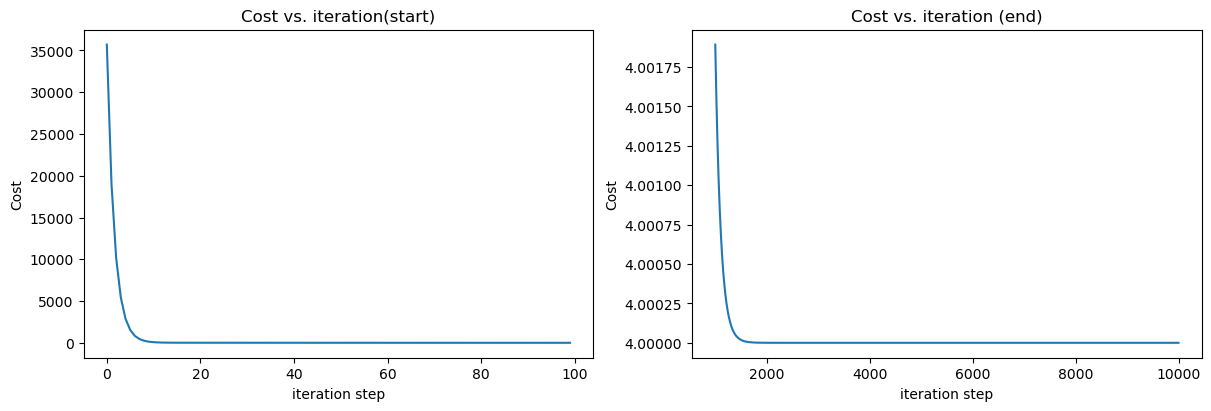

In [238]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

### Cell 7 — Gradient Descent with a Large Alpha (Experiment)

Intentionally runs gradient descent with a very large learning 
rate to observe what happens when alpha is too big.

**Settings:**
- `iterations = 10` — only 10 steps needed, it breaks fast
- `tmp_alpha = 8e-1` — 0.8, massively larger than our working 0.05

**What to expect:**
Instead of cost decreasing smoothly, it will oscillate or 
explode. The model overshoots the minimum on every step —
it jumps past the bottom of the curve and up the other side,
getting worse not better.

**Why this is useful to know:**
Alpha too small → converges but very slowly
Alpha just right → converges smoothly ✓
Alpha too large → overshoots, cost increases or hits `nan`

Choosing alpha is one of the most important decisions when 
training a model. This cell demonstrates why.

In [239]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 7.41e+05  dj_dw: -7.760e+02, dj_db: -3.500e+02   w:  6.208e+02, b: 2.80000e+02
Iteration    1: Cost 8.20e+06  dj_dw:  2.578e+03, dj_db:  1.172e+03   w: -1.441e+03, b:-6.57280e+02
Iteration    2: Cost 9.07e+07  dj_dw: -8.576e+03, dj_db: -3.890e+03   w:  5.420e+03, b: 2.45459e+03
Iteration    3: Cost 1.00e+09  dj_dw:  2.852e+04, dj_db:  1.294e+04   w: -1.740e+04, b:-7.90072e+03
Iteration    4: Cost 1.11e+10  dj_dw: -9.487e+04, dj_db: -4.305e+04   w:  5.850e+04, b: 2.65366e+04
Iteration    5: Cost 1.23e+11  dj_dw:  3.155e+05, dj_db:  1.432e+05   w: -1.939e+05, b:-8.80073e+04
Iteration    6: Cost 1.36e+12  dj_dw: -1.049e+06, dj_db: -4.762e+05   w:  6.456e+05, b: 2.92965e+05
Iteration    7: Cost 1.50e+13  dj_dw:  3.491e+06, dj_db:  1.584e+06   w: -2.147e+06, b:-9.74164e+05
Iteration    8: Cost 1.66e+14  dj_dw: -1.161e+07, dj_db: -5.268e+06   w:  7.141e+06, b: 3.24034e+06
Iteration    9: Cost 1.84e+15  dj_dw:  3.861e+07, dj_db:  1.752e+07   w: -2.375e+07, b:-1.07772e+07


### Cell 8 — Plot Price vs Size

Visualizes the final trained model against the actual training data.

**What we're plotting:**
- Red `x` markers — actual house prices from training data
- Blue line — our learned regression line using `w_final` and `b_final`

**Code breakdown:**
- `np.arange(min, max, 0.1)` — creates smooth x values for the line
  so it draws as a continuous curve, not just 5 dots connected
- `w_final * x_line + b_final` — our hypothesis applied to every point

**What a good result looks like:**
The line should pass cleanly through or close to all the red markers.
If it misses badly, the model hasn't converged properly.

Iteration    0: Cost 3.57e+04  dj_dw: -7.760e+02, dj_db: -3.500e+02   w:  3.880e+01, b: 1.75000e+01
Iteration 1000: Cost 4.00e+00  dj_dw: -7.767e-03, dj_db:  1.712e-02   w:  1.519e+02, b: 4.61843e+01
Iteration 2000: Cost 4.00e+00  dj_dw: -7.547e-05, dj_db:  1.663e-04   w:  1.520e+02, b: 4.60018e+01
Iteration 3000: Cost 4.00e+00  dj_dw: -7.333e-07, dj_db:  1.616e-06   w:  1.520e+02, b: 4.60000e+01
Iteration 4000: Cost 4.00e+00  dj_dw: -7.125e-09, dj_db:  1.570e-08   w:  1.520e+02, b: 4.60000e+01
Iteration 5000: Cost 4.00e+00  dj_dw: -6.926e-11, dj_db:  1.526e-10   w:  1.520e+02, b: 4.60000e+01
Iteration 6000: Cost 4.00e+00  dj_dw: -8.527e-13, dj_db:  1.421e-12   w:  1.520e+02, b: 4.60000e+01
Iteration 7000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01
Iteration 8000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01
Iteration 9000: Cost 4.00e+00  dj_dw: -2.785e-13, dj_db:  6.253e-14   w:  1.520e+02, b: 4.60000e+01


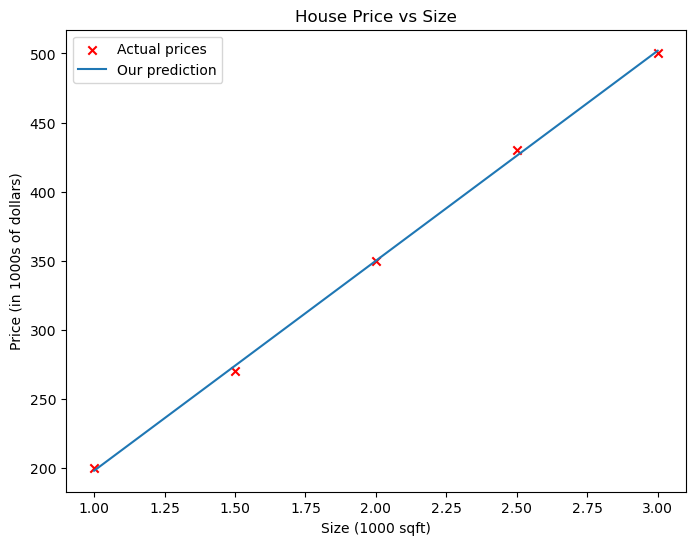

In [240]:
# re-train with correct parameters
tmp_alpha = 5e-2
iterations = 10000
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, 0, 0, tmp_alpha,
                                                     iterations, compute_cost, compute_gradient)

# plot price vs size
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# plot training data points
ax.scatter(x_train, y_train, marker='x', c='r', label="Actual prices")

# plot regression line
x_line = np.arange(min(x_train), max(x_train) + 0.1, 0.1)
y_line = w_final * x_line + b_final
ax.plot(x_line, y_line, label="Our prediction")

ax.set_title("House Price vs Size")
ax.set_ylabel('Price (in 1000s of dollars)')
ax.set_xlabel('Size (1000 sqft)')
ax.legend()
plt.show()